Dependencies

In [67]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

keras.utils.set_random_seed(42)

Loading Dataset

In [68]:
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

In [69]:
labels = ['T-shirt/top',
          'Trousers',
          'Pullover',
          'Dress',
          'Coat',
          'Sandal',
          'Shirt',
          'Sneaker',
          'Bag',
          'Ankle Boot']

Plotting Functions

In [70]:
def plot_loss_curves(history):
  plt.clf()
  history_dict = history.history
  loss_values = history_dict['loss']
  val_loss_values = history_dict['val_loss']
  epochs = range(1, len(loss_values) + 1)
  plt.plot(epochs, loss_values, 'bo', label='Training loss')
  plt.plot(epochs, val_loss_values, 'b', label='validation loss')
  plt.title('Training and validation loss')
  plt.xlabel('Epochs')
  plt.ylabel('Loss')
  plt.legend()
  plt.show()

In [71]:
def plot_acc_curves(history):
  plt.clf()
  history_dict = history.history
  acc = history_dict["accuracy"]
  val_acc = history_dict['val_accuracy']
  epochs = range(1, len(acc) + 1)
  plt.plot(epochs, acc, 'bo', label='Training Acc')
  plt.plot(epochs, val_acc, 'b', label='Validation Acc')
  plt.title('Training and validation accuracy')
  plt.xlabel('Epochs')
  plt.ylabel('Accuracy')
  plt.legend()
  plt.show()

Normalizing training anad testing dataset

In [72]:
x_train = x_train/ 255.0
x_test = x_test/ 255.0
x_train.shape
# x_train = x_train/ 255.0
# x_test = x_test/ 255.0

(60000, 28, 28)

Expanding current data set with 1 extra dimension

In [73]:
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)
# x_train = np.expand_dims(x_train, -1)
# x_test = np.expand_dims(x_test, -1)

In [74]:
x_train.shape

(60000, 28, 28, 1)

In [75]:
# # input layer
# input = keras.Input(shape=x_train.shape[1:])

# # the first convolution box
# # convolutional layer
# x = keras.layers.Conv2D(32,
#                         kernel_size = (2,2),
#                         activation = 'relu',
#                         name='Conv_1')(input)
# # pooling layer
# x = keras.layers.MaxPool2D()(x)
# # end of first convolution box

# # the second convolution box
# # convolution layer
# x = keras.layers.Conv2D(32,
#                         kernel_size=(2,2),
#                         activation='relu',
#                         name='Conv_2')(x)
# # pooling layer
# x = keras.layers.MaxPool2D()(x)
# # end of second convolution block
# #
# # flatten layer
# x = keras.layers.Flatten()(x)
# #
# # fully connected(dense) ReLU layer
# x = keras.layers.Dense(256, activation='relu')(x)

# # output softmax layer
# output = keras.layers.Dense(10, activation='softmax')(x)

# model = keras.Model(input, output)

NN Model

In [76]:
# input layer
input = keras.Input(shape=x_train.shape[1:])

#
# the first convolutional block
#
# convolutional layer
x = keras.layers.Conv2D(64,                    # Number of filters
                        kernel_size=(2, 2),    # The shape of each filter
                        activation="tanh",     # RELU activation as usual
                        name="Conv_1")(input)
# pooling layer
x = keras.layers.MaxPool2D()(x)
# end of first convolutional block

#
# the second convolutional block
#
# convolutional layer
x = keras.layers.Conv2D(64,                    # Number of filters
                        kernel_size=(2, 2),    # The shape of each filter
                        activation="tanh",     # RELU activation as usual
                        name="Conv_2")(x)
# pooling layer
x = keras.layers.MaxPool2D()(x)
# end of second convolutional block

# flatten layer
x = keras.layers.Flatten()(x)

# fully-connected (dense) ReLU layer
x = keras.layers.Dense(256, activation="tanh")(x)

# output softmax layer
output = keras.layers.Dense(10, activation="softmax")(x)


model = keras.Model(input, output)

In [77]:
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_1 (Conv2D)                 │ (None, 27, 27, 64)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_2 (Conv2D)                 │ (None, 12, 12, 64)     │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 609,418 (2.32 MB)

 Trainable params: 609,418 (2.32 MB)

 Non-trainable params: 0 (0.00 B)

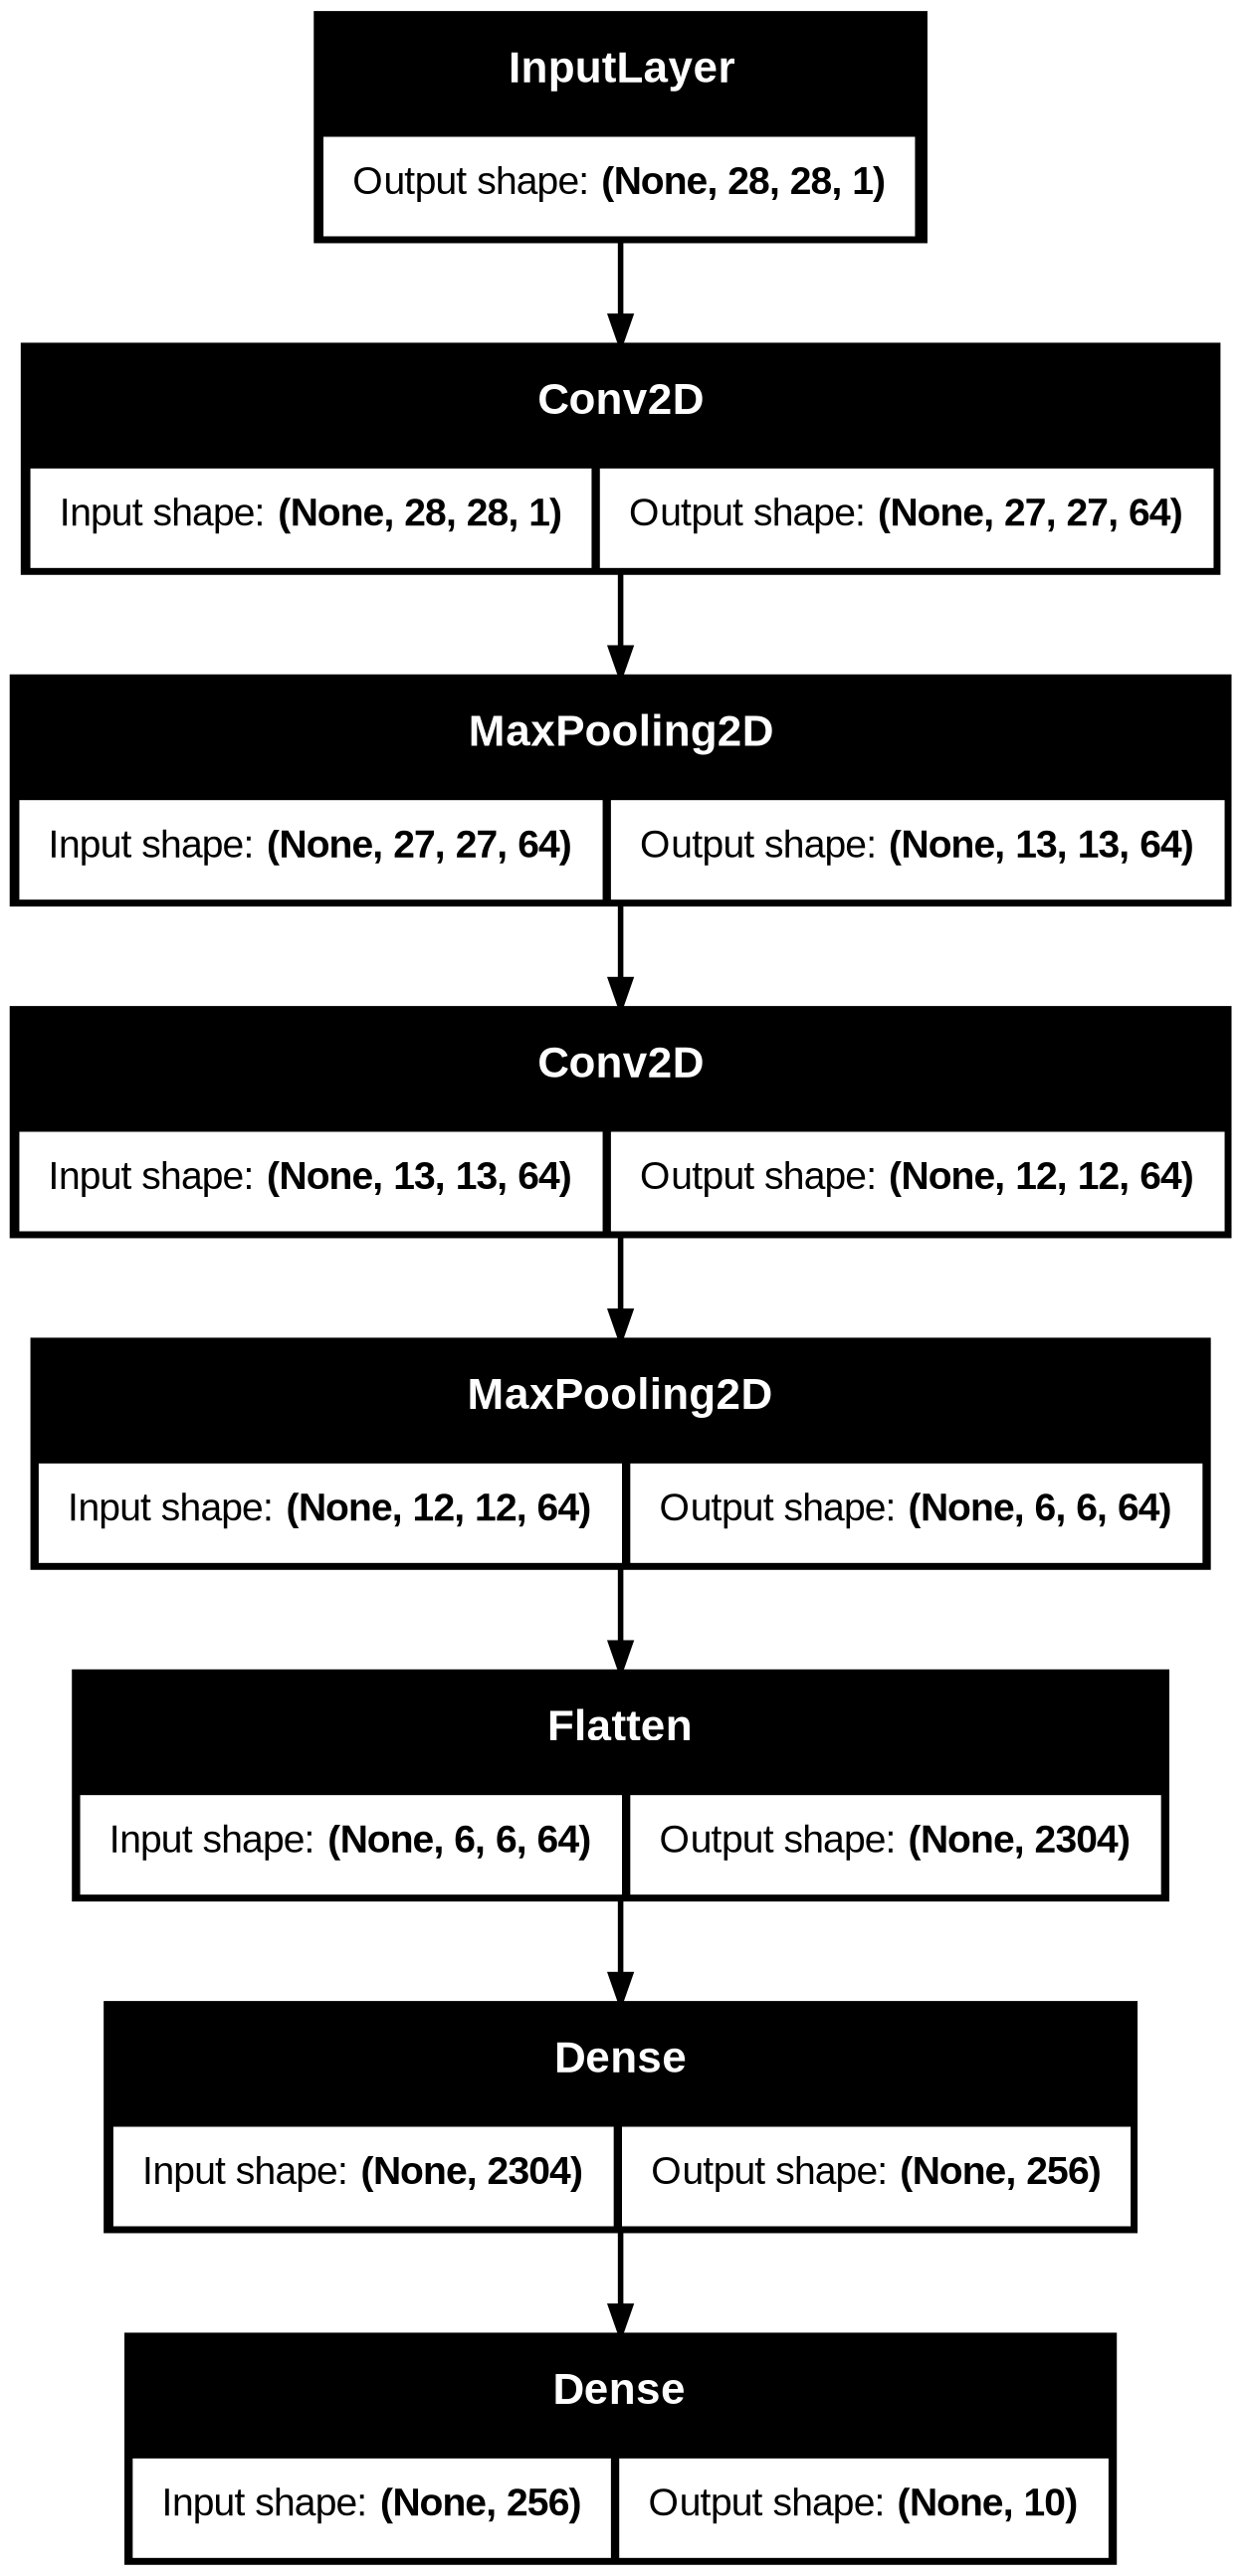

In [78]:
keras.utils.plot_model(model, show_shapes=True)

Optimization Parameters

In [79]:
model.compile(loss='sparse_categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

Modle Training

In [80]:
history = model.fit(x_train,
                    y_train,
                    batch_size=64,
                    epochs=10,
                    validation_split=0.2)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8432 - loss: 0.4349 - val_accuracy: 0.8782 - val_loss: 0.3416
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8902 - loss: 0.3028 - val_accuracy: 0.8897 - val_loss: 0.3015
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9063 - loss: 0.2551 - val_accuracy: 0.8996 - val_loss: 0.2727
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9198 - loss: 0.2169 - val_accuracy: 0.9078 - val_loss: 0.2589
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9341 - loss: 0.1824 - val_accuracy: 0.9084 - val_loss: 0.2598
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9476 - loss: 0.1499 - val_accuracy: 0.9063 - val_loss: 0.2727
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9597 - loss: 0.1208 - val_accuracy: 0.9041 - val_loss: 0.2845
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9682 - loss: 0.0971 - val_accuracy: 0.

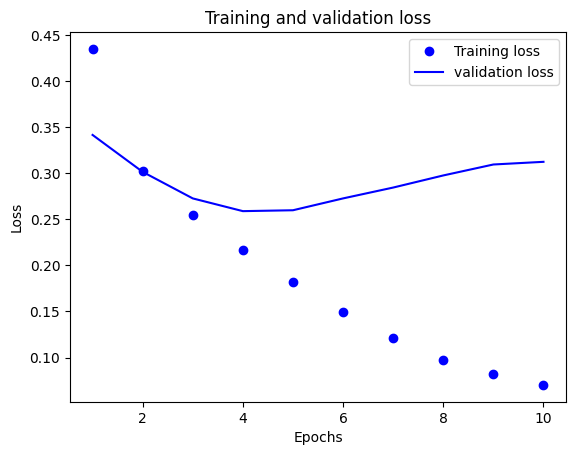

In [81]:
plot_loss_curves(history)

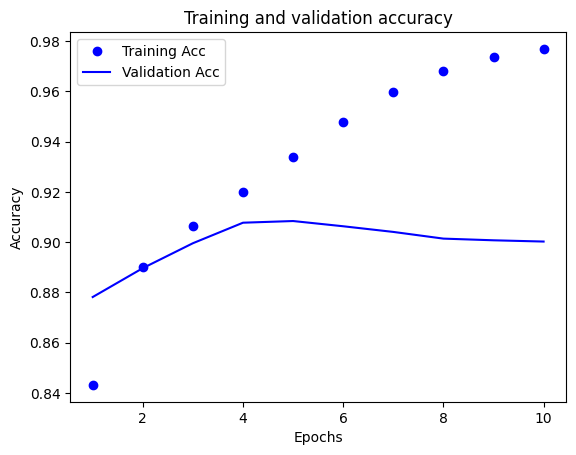

In [82]:
plot_acc_curves(history)

Checking accuracy on training dataset

In [83]:
score = model.evaluate(x_test, y_test)
print('Test accuracy:', score[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8998 - loss: 0.3306
Test accuracy: 0.8998000025749207


In [84]:
# get the predictions
y_hat = np.argmax(model.predict(x_test), axis=1)

# collect examples where the model made a mistake
misses = np.where(y_hat != y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


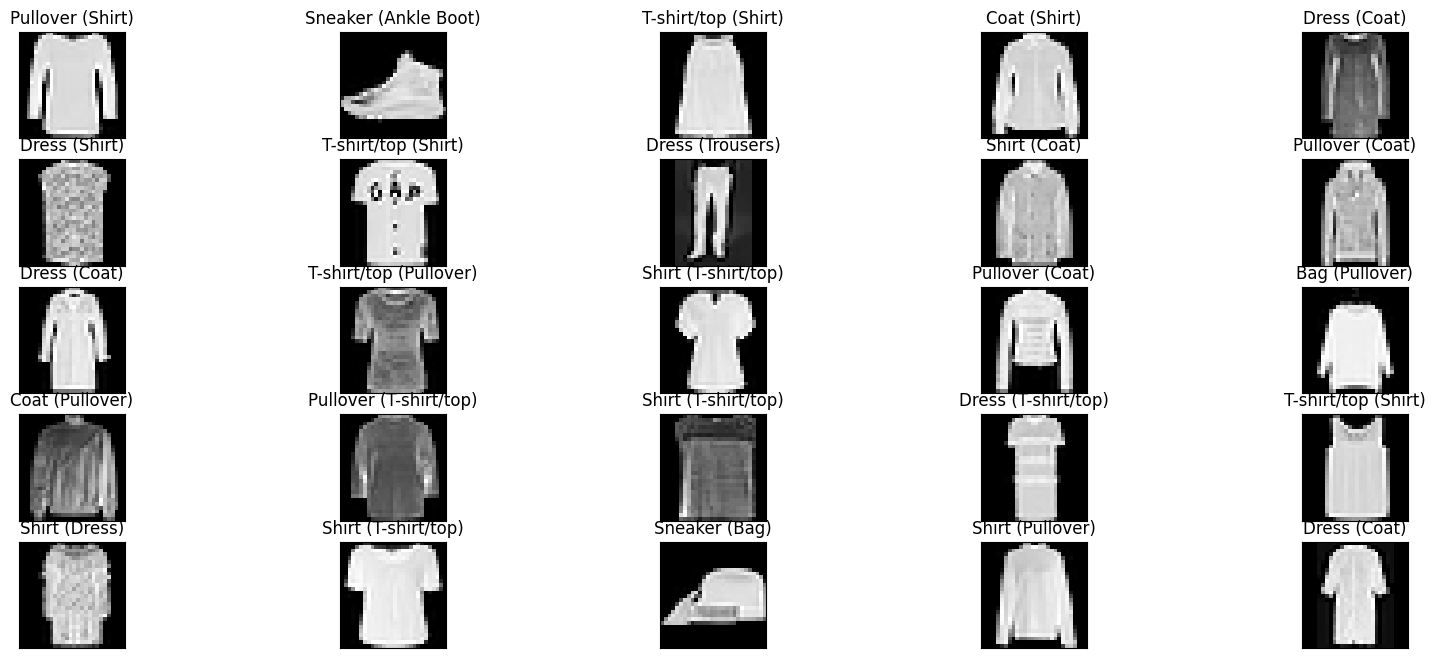

In [85]:
# Plot a random sample of 25 test images incorrectly classified by the model,
# their predicted labels and ground truth
figure = plt.figure(figsize=(20,8))
for i, index in enumerate(np.random.choice(misses[0], size=25, replace=False)):
    ax = figure.add_subplot(5, 5, i + 1, xticks=[], yticks=[])
    # Display each image
    ax.imshow(np.squeeze(x_test[index]), cmap="gray")
    # Set the title for each image
    ax.set_title("{} ({})".format(labels[y_hat[index]],
                                  labels[y_test[index]]))

In [86]:
actuals = [labels[i] for i in y_test]
predictions = [labels[i] for i in y_hat]

In [87]:
df = pd.DataFrame({'Predictions': predictions, 'Actuals': actuals})
pd.crosstab(df.Predictions, df.Actuals)

Actuals,Ankle Boot,Bag,Coat,Dress,Pullover,Sandal,Shirt,Sneaker,T-shirt/top,Trousers
Predictions,,,,,,,,,,
Ankle Boot,964,1,0,0,0,3,0,39,0,0
Bag,0,977,2,2,3,2,13,0,6,1
Coat,0,0,790,18,29,0,55,0,3,0
Dress,0,9,29,907,7,0,21,0,12,14
Pullover,0,3,115,10,907,0,103,0,34,1
Sandal,8,1,0,0,0,985,0,20,0,1
Shirt,0,3,63,48,41,0,723,0,119,3
Sneaker,28,3,0,0,0,10,0,941,0,0
T-shirt/top,0,1,1,10,12,0,85,0,825,1
